In [145]:
import pandas as pd
import numpy as np
import seaborn as sns

In [146]:
df = pd.read_csv("data/yelp_restaurants.csv")
df.head()

,id,name,is_closed,review_count,categories,rating,transactions,price,transactions_delivery,transactions_pickup,...,categories_Vegan,categories_Vegetarian,categories_Venues & Event Spaces,categories_Vietnamese,categories_Wine Bars,categories_Wraps,$,$$,$$$,$$$$
0,gZz9A8k8ORC_xl0aHxtY4w,Monkey Bar,False,459,"['American', 'Bars']",4.3,[],NaN,0,0,...,0,0,0,0,0,0,0,0,0,0
1,xt4sa64WOrpJvZBDPNPNYg,Jacob's Pickles,False,5967,"['Comfort Food', 'Southern', 'American']",4.2,"['pickup', 'delivery']",$$,1,1,...,0,0,0,0,0,0,0,1,0,0
2,q1uIqB8PvyCCX8TajaRYBg,Little Owl,False,1548,"['Breakfast & Brunch', 'Mediterranean', 'Ameri...",4.2,"['pickup', 'delivery']",$$$,1,1,...,0,0,0,0,0,0,0,0,1,0
3,ooYUO3Pq_qypc1NXFzeLYQ,City Vineyard,False,1282,"['Wine Bars', 'American', 'Venues & Event Spac...",4.0,"['pickup', 'delivery']",$$$,1,1,...,0,0,1,0,1,0,0,0,1,0
4,V7lXZKBDzScDeGB8JmnzSA,Katz's Delicatessen,False,16926,"['Delis', 'American']",4.1,"['pickup', 'delivery']",$$,1,1,...,0,0,0,0,0,0,0,1,0,0


In [147]:
df['price'] = df['price'].fillna("")
df.shape

(487, 124)

In [148]:
len(df[df['review_count'] == 0])

0

In [149]:
df['rating'].isna().sum()

np.int64(0)

Получается, что оценка присутствует во всех записях

In [150]:
df.duplicated().sum()

np.int64(0)

=> в данных нет дубликатов

Преобразуем категории в списки

In [151]:

df['categories'] = df['categories'].str.replace("'", "").str.replace("]", "").str.replace("[", "").str.split(", ")


In [152]:
exploded_df = df.explode('categories')
avg_rating_by_cuisine = exploded_df.groupby('categories')['rating'].agg(['mean', 'count', 'std'])

Редкие виды кухни:

In [153]:
rare_cuisines = avg_rating_by_cuisine[avg_rating_by_cuisine['count'] < 10].index
rare_cuisines

Index(['African', 'Bakeries', 'Barbeque', 'Beer', 'Beer Bar', 'Beer Gardens',
       'Brasseries', 'British', 'Bubble Tea', 'Buffets', 'Burgers', 'Cafes',
       'Cantonese', 'Caribbean', 'Caterers', 'Chicken Shop', 'Chicken Wings',
       'Coffee & Tea', 'Comfort Food', 'Cuban', 'Delis', 'Diners', 'Falafel',
       'Fast Food', 'Filipino', 'Fondue', 'Food Stands', 'Food Trucks',
       'Gastropubs', 'German', 'Gluten-Free', 'Grocery', 'Halal',
       'Hong Kong Style Cafe', 'Hot Pot', 'Indian', 'Indonesian',
       'International Grocery', 'Izakaya', 'Japanese Curry', 'Jazz & Blues',
       'Kebab', 'Korean', 'Kosher', 'Latin American', 'Lebanese',
       'Live/Raw Food', 'Lounges', 'Malaysian', 'Meat Shops', 'Middle Eastern',
       'Modern European', 'Moroccan', 'Music Venues', 'New Mexican Cuisine',
       'Pan Asian', 'Pasta Shops', 'Persian/Iranian', 'Piano Bars',
       'Sandwiches', 'Shanghainese', 'Sicilian', 'Singaporean', 'Soup',
       'Southern', 'Spanish', 'Speakeasies', 

In [154]:
exploded_df = exploded_df[~exploded_df['categories'].isin(rare_cuisines)]
exploded_df['categories'].value_counts().tail(20)

,count
categories,
Noodles,36
Breakfast & Brunch,34
Mexican,34
Wine Bars,27
Japanese,27
New American,22
Chinese,22
Bars,20
Dim Sum,17


Лучшие по рейтингу среди популярных видов ресторанов:

In [155]:
avg_rating_by_cuisine[avg_rating_by_cuisine["count"] > 20].sort_values('mean', ascending=False).head(10)

,mean,count,std
categories,,,
Japanese,4.429630,27,0.175005
Thai,4.398039,51,0.249391
Cocktail Bars,4.308333,96,0.277457
Noodles,4.297222,36,0.253531
Seafood,4.286364,44,0.263775
Mexican,4.285294,34,0.275387
French,4.270000,50,0.248465
Italian,4.269388,49,0.257556
Wine Bars,4.255556,27,0.291328


Наиболее часто встречающиеся виды ресторанов среди представленных в датасете видов кухни:

In [156]:
avg_rating_by_cuisine.sort_values('count', ascending=False).head(10)

,mean,count,std
categories,,,
Cocktail Bars,4.308333,96,0.277457
Mediterranean,4.236620,71,0.283972
American,4.098333,60,0.328061
Thai,4.398039,51,0.249391
French,4.270000,50,0.248465
Greek,4.234000,50,0.285436
Irish,3.928000,50,0.405090
Italian,4.269388,49,0.257556
Seafood,4.286364,44,0.263775


<Axes: ylabel='categories'>

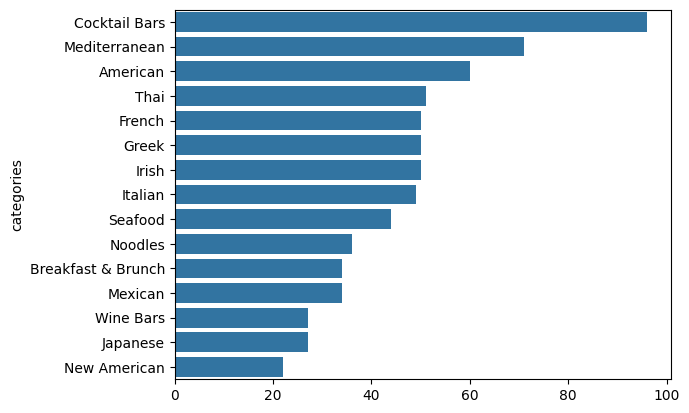

In [157]:
top_cuisines = exploded_df['categories'].value_counts().head(15)

sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

<Axes: xlabel='rating', ylabel='Count'>

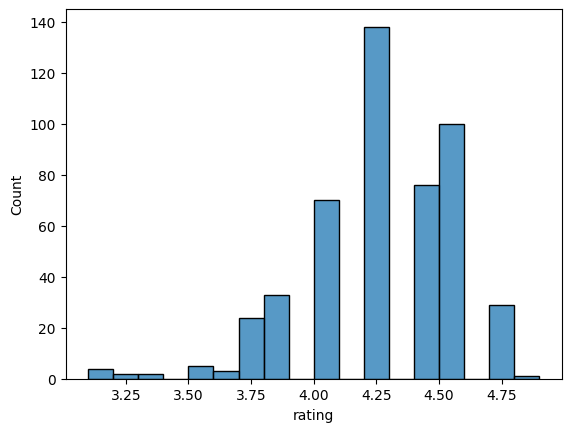

In [158]:
sns.histplot(data=df, x='rating')

Самые популярные по кол-ву отзывов:

In [159]:
df.sort_values('review_count', ascending=False).head(10)[["name", "review_count", "categories", "rating", "transactions", "price"]].reset_index()

,index,name,review_count,categories,rating,transactions,price
0,4,Katz's Delicatessen,16926,"[Delis, American]",4.1,"['pickup', 'delivery']",$$
1,110,IPPUDO NY,10812,[Ramen],4.1,"['delivery', 'pickup']",$$
2,157,Joe's Shanghai,7665,"[Shanghainese, Seafood, Noodles]",3.8,"['pickup', 'delivery']",$$
3,51,Olio e Più,7333,"[Pizza, Italian, Cocktail Bars]",4.5,"['pickup', 'delivery']",$$$
4,344,LoveMama,7053,"[Thai, Malaysian, Vietnamese]",4.4,"['pickup', 'restaurant_reservation', 'delivery']",$$
5,68,Eataly - Flatiron,6472,"[Italian, Pizza, Grocery]",3.9,"['pickup', 'delivery']",$$
6,1,Jacob's Pickles,5967,"[Comfort Food, Southern, American]",4.2,"['pickup', 'delivery']",$$
7,57,Carmine's - Time Square,5521,"[Italian, Venues & Event Spaces, Seafood]",4.0,"['pickup', 'delivery']",$$
8,346,Thai Villa,5295,[Thai],4.4,"['pickup', 'delivery']",$$
9,163,Buddakan,4909,"[Chinese, Bars, Asian Fusion]",4.1,"['pickup', 'delivery']",$$$$


<Axes: xlabel='review_count', ylabel='Count'>

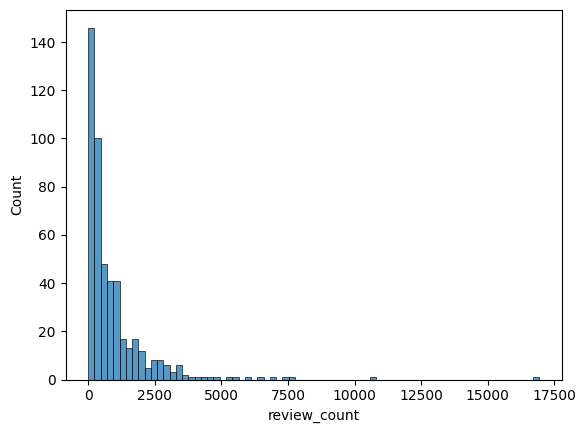

In [160]:
sns.histplot(data=df, x='review_count')

<Axes: xlabel='review_count', ylabel='rating'>

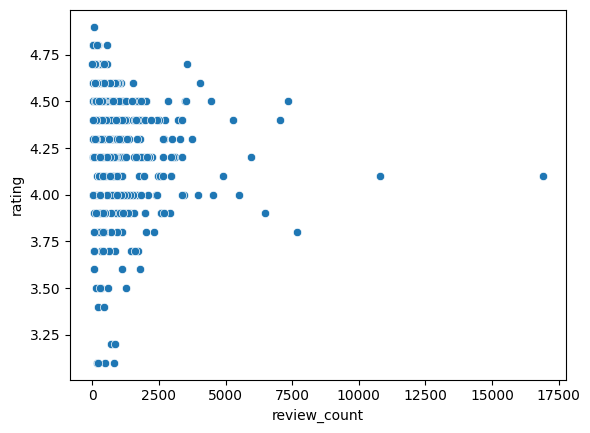

In [161]:
sns.scatterplot(data=df, x='review_count', y='rating')

Присваиваем числовое значение категории цены

In [162]:
df['price_category'] = df["price"].apply(len)

In [163]:
pivot_rating = df.groupby(['price_category'])['rating'].mean().reset_index()
pivot_rating

,price_category,rating
0,0,4.393220
1,1,4.352941
2,2,4.196596
3,3,4.234409
4,4,4.212500


Удаляем категорию 0, т. к. 0 - с неопределенной ценой

In [164]:
pivot_rating = pivot_rating.drop(index=0)

In [165]:
corr_df = pivot_rating.corr()
corr_df

,price_category,rating
price_category,1.000000,-0.697983
rating,-0.697983,1.000000


<Axes: >

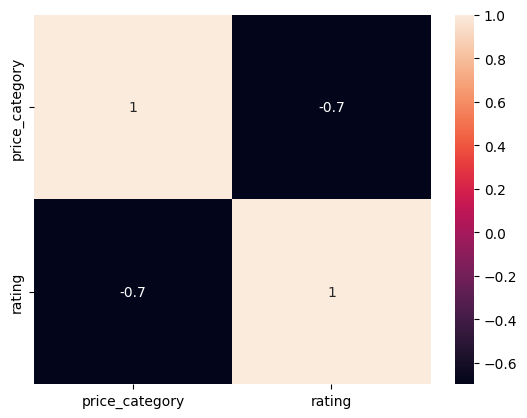

In [166]:
sns.heatmap(corr_df, annot=True)

<Axes: xlabel='price_category', ylabel='rating'>

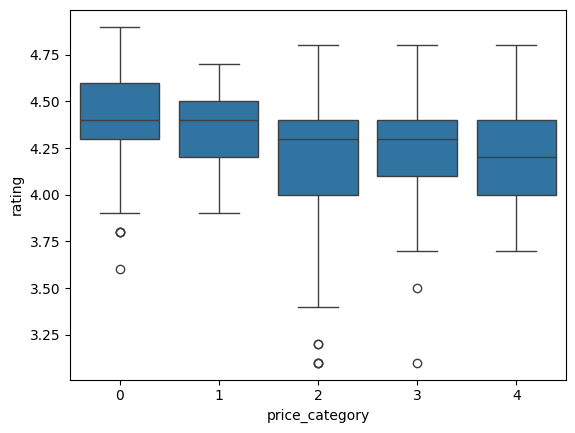

In [167]:
sns.boxplot(data=df, x='price_category', y='rating')